# 3 · Ensembles: de la varianza al modelo final

El VAE `recon_prob` era el mejor, pero **cada semilla converge distinto** → alta
varianza. Solución: **ensemble de semillas**.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 3.1 — Seed-ensemble
Entrenamos N VAEs con semillas distintas y promediamos sus scores normalizados. El
`EnsembleDetector` es agnóstico al modelo. Config y estructura del ensemble final:

In [2]:
explib.describe_architecture("configs/ensemble/vae_seedens_v1.yaml")

Modelo: Ensemble (10 miembros, combine=mean, normalize=zscore)
  Cada miembro:
Modelo: VAE
  Encoder:  54 → 64 → 32 → 16 (latente)
  Decoder:  16 → 32 → 64 → 54
  Score:    recon_prob  (recon_prob = -E[log p(x|z)], pondera por varianza per-feature)
  beta(KL): 1.0

  Optimización: lr=0.001 epochs=300 patience=30 batch=64 n_seeds=—

  Optimización: lr=— epochs=— patience=— batch=— n_seeds=3


In [3]:
ens = [("vae_v4_reconprob_lat16","VAE single"), ("vae_seedens_v1","seed-ens ×10 (lat16)"),
       ("vae_seedens_deep","seed-ens ×10 (deep)"), ("vae_iforest_ens_v1","hetero VAE+IForest")]
explib.show(explib.compare_table(ens, "soja", era="clean"))

,modelo,PR-AUC,ROC-AUC,F1,Precision@k,Recall@contam
0,VAE single,0.559±0.035,0.719±0.027,0.486±0.026,0.518±0.035,0.279±0.018
1,seed-ens ×10 (lat16),0.592±0.010,0.738±0.005,0.467±0.001,0.558±0.013,0.297±0.002
2,seed-ens ×10 (deep),0.585±0.007,0.749±0.005,0.519±0.004,0.555±0.010,0.296±0.006
3,hetero VAE+IForest,—,—,—,—,—


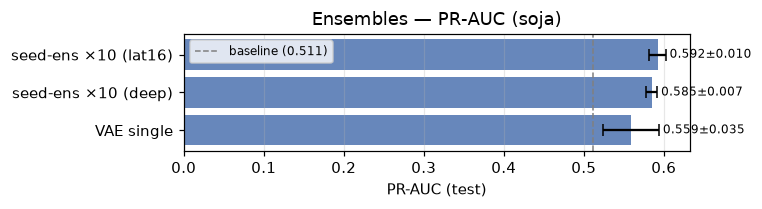

In [4]:
explib.plot_compare(ens, "soja", era="clean", baseline=0.511, title="Ensembles — PR-AUC (soja)"); plt.show()

El **desvío se desploma** (±0.035 → ±0.010) y la media *sube*: el promedio cancela el
ruido idiosincrático de cada semilla. El hetero VAE+IForest queda mixto (el IForest arrastra).

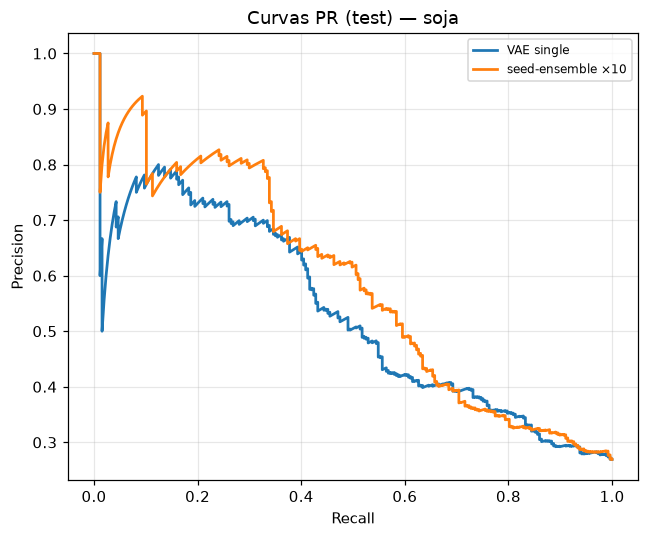

In [5]:
explib.plot_pr_curves([("vae_v4_reconprob_lat16","VAE single"),
                       ("vae_seedens_v1","seed-ensemble ×10")], "soja"); plt.show()

## 3.2 — La idea de *Dataset Cartography* (la del profesor)
"Lo que el modelo predice **siempre** mal es anomalía". La implementamos como **diagnóstico**:
- **Data map** (Swayamdipta 2020): error de reconstrucción de cada muestra **por época** →
  *confidence* (error medio) + *variability* (desvío entre épocas).
- **Desacuerdo del ensemble** (`score_std`): desvío entre miembros = incertidumbre.

> **El modelo final NO usa cartography para puntuar** (es el promedio simple del ensemble).
> Fue herramienta para *auditar* (NB 5): mostró que lo "siempre mal reconstruido" es rareza
> climática, no anomalía de rinde. Lo dejamos porque responde la pregunta del profesor.

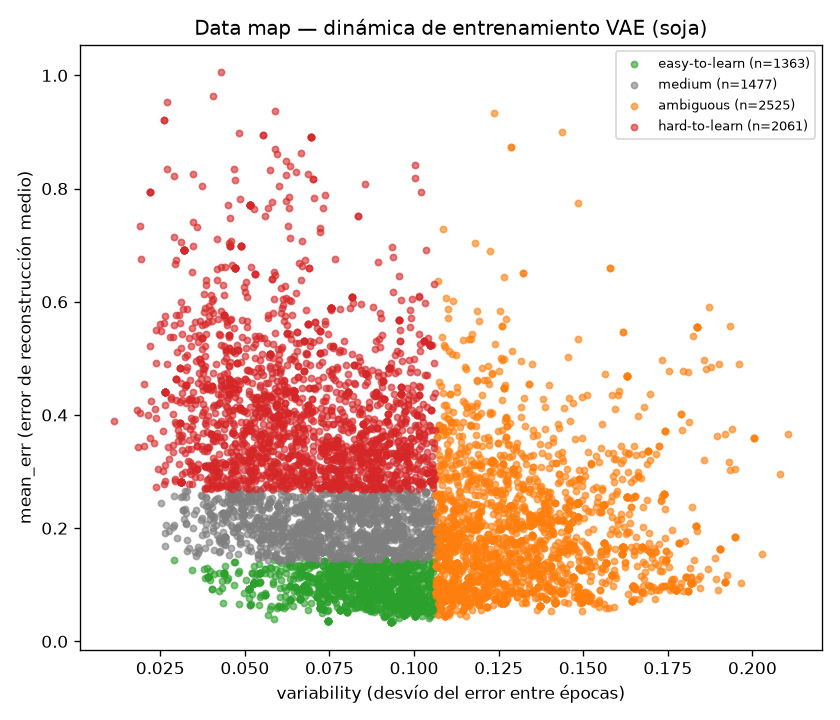

In [6]:
from IPython.display import Image, display
p = os.path.join(explib.ROOT, "analysis", "datamap_soja.png")
display(Image(p)) if os.path.exists(p) else print("generar: python analyze_datamap.py --cultivo soja")

## 3.3 — El modelo final: `vae_seedens_v1` (todas sus métricas, ±std)

In [7]:
explib.show(explib.run_metrics("vae_seedens_v1", "soja"))

,metrica,valor,std
0,PR-AUC,0.5921,0.0101
1,ROC-AUC,0.7380,0.0050
2,F1,0.4667,0.0008
3,Precision@k,0.5577,0.0128
4,Recall@contam,0.2970,0.0018


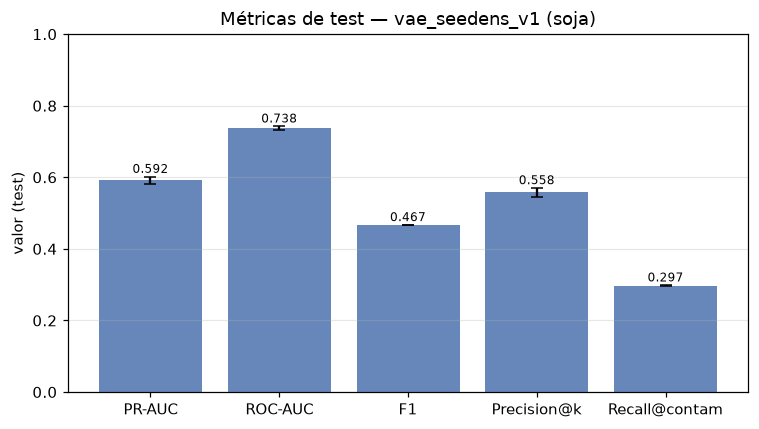

In [8]:
explib.plot_all_metrics("vae_seedens_v1", "soja"); plt.show()

**Modelo final del Componente A.** En los próximos notebooks intentamos superarlo (datos nuevos, modernos) sin éxito.